Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Model saved successfully!
[175140.71428571  99568.31349206 128055.83333333  95763.33333333
 166155.23809524 164726.01190476 138734.28571429 106405.
  51094.12698413 101088.98809524 135624.6969697  139785.11904762
  41723.11507937  98205.54112554 129318.80952381  51094.12698413
  57645.47619048  42375.35714286  91328.92857143  97583.12049062
 110222.97619048 108591.78571429 155521.74603175  60791.01190476
  95763.33333333  52589.43722944 155583.57142857  39961.30952381
  99409.04761905 154816.48809524  45875.65295815 110755.89285714
  48566.95707071 148544.33982684  97857.19932845  37988.21428571
 171634.56349206  39577.06666667 154883.63095238  61641.60714286
  40000.         100306.67207792 143490.95238095 175192.79220779
  39696.97619048 167644.76190476 112050.47619048  42802.6984127
  39577.06666667  40047.02380952 160920.13888889  92385.1984127
 127037.85714286  89310.6547619  1

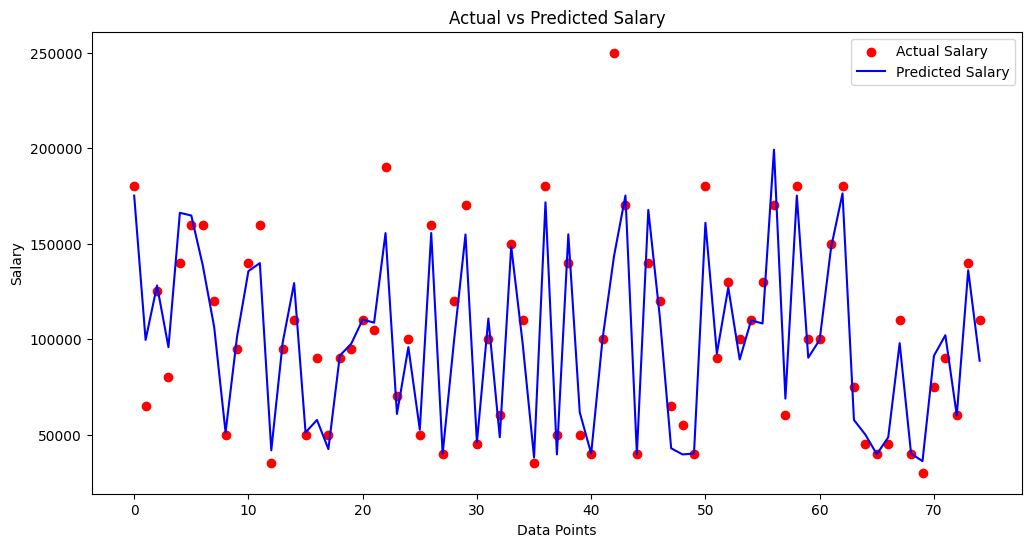

R2 Score: 0.8658472984493593
0.9607769897962452 0.8658472984493593


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib

data = pd.read_csv('Salary Data.csv')

data = data.dropna()

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [1, 2, 3])], remainder='passthrough'
)

X = np.array(ct.fit_transform(X))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
     'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

model = GridSearchCV(RandomForestRegressor(random_state = 0), param_grid, cv=5, scoring='r2')
model.fit(X_train, y_train)

print("Best Parameters:", model.best_params_)
best_model = model.best_estimator_

# Save model and encoder
joblib.dump(best_model, "salary_model.pkl")
joblib.dump(ct, "encoder.pkl")

print("Model saved successfully!")

y_pred = best_model.predict(X_test)

print(y_pred)
plt.figure(figsize=(12,6))

# Actual values as scatter
plt.scatter(
    range(len(y_test)),
    y_test,
    color='red',
    label='Actual Salary'
)

# Predicted values as line
plt.plot(
    range(len(y_pred)),
    y_pred,
    color='blue',
    label='Predicted Salary'
)

plt.xlabel("Data Points")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()

plt.show()

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print(train_score, test_score)